### Imports and Paths

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import TransformerConv
from tqdm import trange
import matplotlib.pyplot as plt
from pathlib import Path

# Base paths
base_dir = Path("C:/Users/mills/Desktop/Angione Lab/OC")
adata_path = base_dir / "OC_adata_hvg.h5ad"
output_path = base_dir / "spatial" / "OC_adata_hvg_graph_gene.h5ad"

# Create folder if it doesn't exist
output_path.parent.mkdir(exist_ok=True)

### Load HVG AnnData

In [2]:
adata = sc.read_h5ad(adata_path)
print("Loaded AnnData:", adata.shape)
adata

Loaded AnnData: (63072, 150)


AnnData object with n_obs × n_vars = 63072 × 150
    obs: 'fov', 'volume', 'center_x', 'center_y', 'min_x', 'max_x', 'min_y', 'max_y', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'outlier', 'doublet_score', 'predicted_doublet', 'leiden'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

### Spatial Coordinate Processing

In [3]:
coords = adata.obs[["center_x", "center_y"]].values
scaler_coords = StandardScaler()
coords_scaled = scaler_coords.fit_transform(coords)
print("Scaled spatial coordinates:", coords_scaled.shape)

Scaled spatial coordinates: (63072, 2)


### K-Nearest Neighbour Graph Construction

In [4]:
k = 10
nbrs = NearestNeighbors(n_neighbors=k)
nbrs.fit(coords_scaled)
distances, indices = nbrs.kneighbors(coords_scaled)

edges = []
for i in range(indices.shape[0]):
    for j in indices[i]:
        if i != j:
            edges.append([i, j])

edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
print("Edge index shape:", edge_index.shape)

Edge index shape: torch.Size([2, 567648])


### Graph Data Object Creation

In [5]:
x = torch.tensor(adata.X, dtype=torch.float)
data = Data(x=x, edge_index=edge_index)
print(data)

Data(x=[63072, 150], edge_index=[2, 567648])


### Graph Transformer Model Definition

In [6]:
class GraphTransformer(nn.Module):
    def __init__(self, in_channels, hidden=128):
        super().__init__()
        self.conv1 = TransformerConv(in_channels, hidden, heads=2)
        self.conv2 = TransformerConv(hidden*2, hidden, heads=2)
        self.lin = nn.Linear(hidden*2, in_channels)  # reconstruct gene features

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.lin(x)
        return x

### Model Training

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GraphTransformer(in_channels=data.x.shape[1]).to(device)
data = data.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

### Training Loss Visualization

In [8]:
epochs = 200
loss_history = []

pbar = trange(epochs, desc="Training GNN", unit="epoch")
for epoch in pbar:
    optimizer.zero_grad()
    embeddings = model(data.x, data.edge_index)
    loss = F.mse_loss(embeddings, data.x)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())
    pbar.set_description(f"Epoch {epoch+1} | Loss: {loss.item():.4f}")

Epoch 200 | Loss: 0.0714: 100%|██████████| 200/200 [13:35<00:00,  4.08s/epoch]


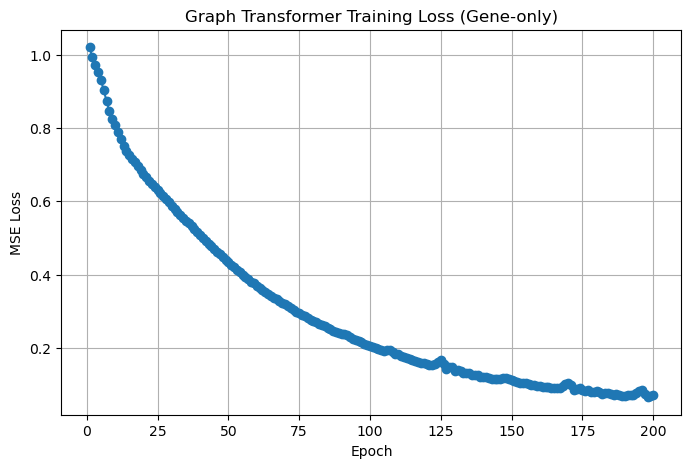

In [9]:
plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), loss_history, marker='o', linestyle='-')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Graph Transformer Training Loss (Gene-only)")
plt.grid(True)
plt.show()

### Embedding Extraction and Saving

In [10]:
model.eval()
with torch.no_grad():
    graph_embeddings = model(data.x, data.edge_index).cpu().numpy()

adata.obsm["X_graph_gene"] = graph_embeddings
adata.write(output_path)
print("Graph embeddings saved to:", output_path)

Graph embeddings saved to: C:\Users\mills\Desktop\Angione Lab\OC\spatial\OC_adata_hvg_graph_gene.h5ad
